# Fase 2 — Preprocesamiento EEG: visualización antes/después

Este notebook **no contiene lógica**: importa la maquinaria de `src/preprocessing.py` y la
ejecuta sobre **un segmento de un paciente** para VER qué le hace cada uno de los 6 pasos a la
señal. El notebook es la lupa; el batch (`preprocessing.run_batch`) es la línea de producción.

El *porqué* de cada paso está en el log `logs/2026-07-08 - Fase 2 - por qué de cada paso...`.

In [6]:
import sys
from pathlib import Path

# La maquinaria vive en ../src. La añadimos al path para importarla.
sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
import mne

import preprocessing as pp
from config import DATA_DIR

PATIENT = "0284"          # paciente a visualizar
VIZ_CHANNEL = "Fp1"       # canal a mostrar en detalle
ch_idx = pp.CANONICAL_CHANNELS.index(VIZ_CHANNEL)
print("preprocessing importado; pipeline:", pp.BANDPASS_HZ, "Hz |", pp.EPOCH_SEC, "s/época")

preprocessing importado; pipeline: (0.5, 45.0) Hz | 10.0 s/época


In [7]:
mne.read_epochs("../data_processed/patient_0311-epo.fif")

<EpochsFIF | 2000 events (all good), 0 – 9.99 s (baseline off), ~289.9 MiB, data loaded, with metadata,
 '1': 2000>

## 1. Cargar UN segmento crudo (ya seleccionado a 19 canales canónicos)

In [8]:
patient_dir = DATA_DIR / PATIENT
records = pp.in_window_eeg_records(patient_dir)
print(f"{PATIENT}: {len(records)} segmentos en la ventana 24-72h")

# Cargamos el primero: load_segment_as_raw ya hace el paso 1 (selección de canales).
raw_sel, utility_freq = pp.load_segment_as_raw(patient_dir / records[1])
print(f"Segmento {records[0]} | red eléctrica: {utility_freq} Hz "
      f"| sfreq: {raw_sel.info['sfreq']} Hz | canales: {len(raw_sel.ch_names)}")

0284: 59 segmentos en la ventana 24-72h
Segmento 0284_025_024_EEG | red eléctrica: 50 Hz | sfreq: 500.0 Hz | canales: 19


In [9]:
raw_sel.info

<Info | 7 non-empty values
 bads: []
 ch_names: Fp1, Fp2, F7, F3, Fz, F4, F8, T3, C3, Cz, C4, T4, T5, P3, Pz, ...
 chs: 19 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 250.0 Hz
 meas_date: unspecified
 nchan: 19
 projs: []
 sfreq: 500.0 Hz
>

## 2. Helpers de visualización

Dos funciones: una dibuja la señal en el **tiempo** y otra su **PSD** (cuánta energía hay en cada
frecuencia, vía Welch). Nada de esto altera los datos.

In [10]:
def get_signal(raw):
    return raw.get_data(), raw.info["sfreq"]

def plot_time(ax, data, sfreq, title, seconds=10, color="#1a73e8"):
    n = min(int(seconds * sfreq), data.shape[1])
    t = np.arange(n) / sfreq
    ax.plot(t, data[ch_idx, :n], lw=0.6, color=color)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("tiempo (s)"); ax.set_ylabel("amplitud (nu)")
    ax.grid(alpha=0.3)

def plot_psd(ax, data, sfreq, label, color):
    freqs, psd = welch(data[ch_idx], fs=sfreq, nperseg=int(2 * sfreq))
    ax.semilogy(freqs, psd, color=color, lw=1.1, label=label)

## 3. Aplicar los pasos 2-4 y capturar la señal en cada etapa

`filter_raw`, `resample_raw` y `rereference_car` modifican el objeto in place, así que trabajamos
sobre una copia y guardamos una foto de la señal tras cada paso.

In [11]:
stages = {}
stages["1 · 19 canales (crudo)"] = get_signal(raw_sel)

raw = raw_sel.copy()
pp.filter_raw(raw, utility_freq)          # paso 2: notch + pasa-banda
stages["2 · notch + pasa-banda"] = get_signal(raw)

pp.resample_raw(raw)                       # paso 3: 100 Hz
stages["3 · re-muestreo 100 Hz"] = get_signal(raw)

pp.rereference_car(raw)                     # paso 4: CAR
stages["4 · CAR"] = get_signal(raw)

for name, (d, fs) in stages.items():
    print(f"{name:26s}  shape={d.shape}  sfreq={fs} Hz")

1 · 19 canales (crudo)      shape=(19, 1569000)  sfreq=500.0 Hz
2 · notch + pasa-banda      shape=(19, 1569000)  sfreq=500.0 Hz
3 · re-muestreo 100 Hz      shape=(19, 313800)  sfreq=100.0 Hz
4 · CAR                     shape=(19, 313800)  sfreq=100.0 Hz


## 4. Dominio del tiempo — la señal tras cada paso

Fíjate cómo tras el filtro la señal deja de "flotar" (se va la deriva lenta) y se centra en cero.

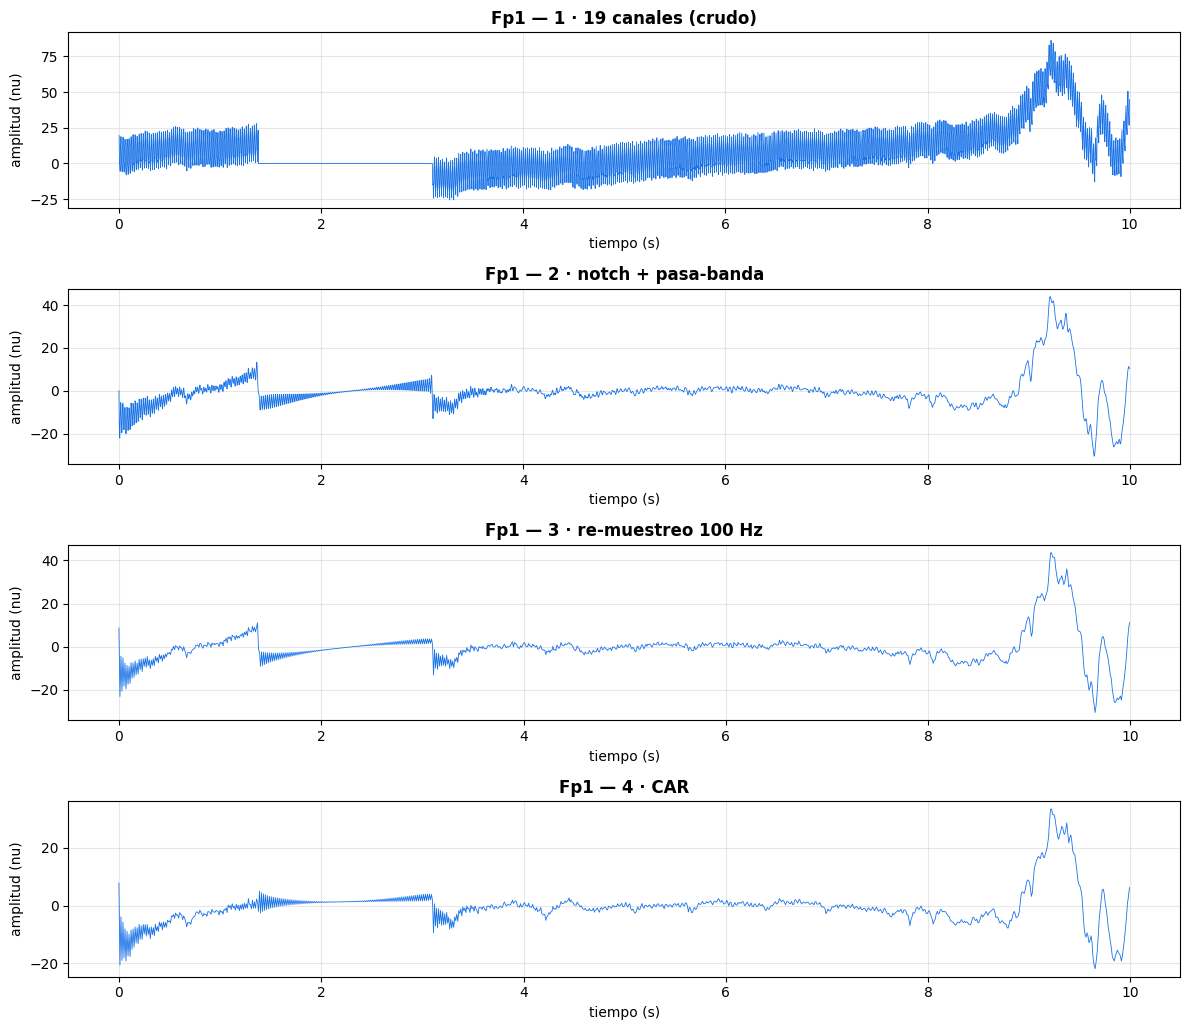

In [12]:
fig, axes = plt.subplots(len(stages), 1, figsize=(12, 2.6 * len(stages)))
for ax, (title, (d, fs)) in zip(axes, stages.items()):
    plot_time(ax, d, fs, f"{VIZ_CHANNEL} — {title}")
plt.tight_layout(); plt.show()

## 5. Dominio de la frecuencia — PSD crudo vs procesado

La prueba de fuego del filtrado. En la curva procesada (azul) debe verse: caída en picada por
debajo de 0.5 Hz y por encima de 45 Hz, y **sin pico** en la línea roja de la red eléctrica.

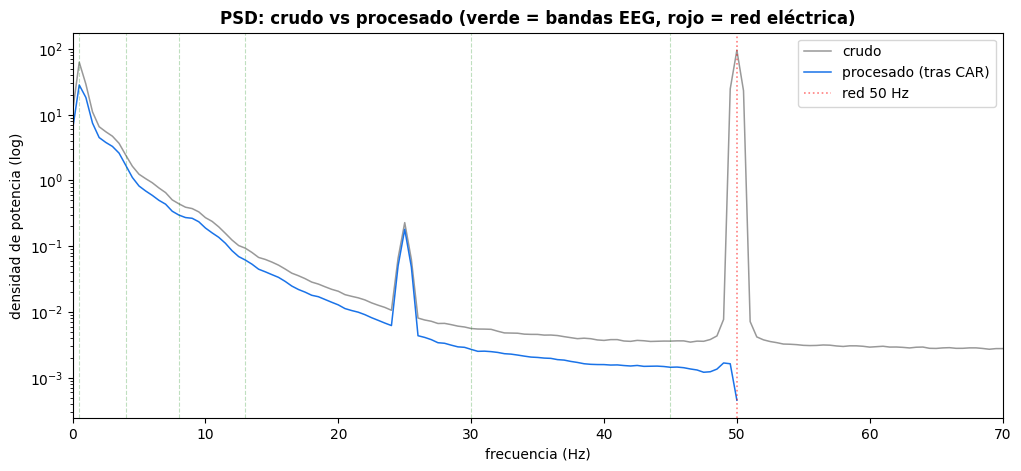

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))
d0, fs0 = stages["1 · 19 canales (crudo)"]
d1, fs1 = stages["4 · CAR"]
plot_psd(ax, d0, fs0, "crudo", "#999999")
plot_psd(ax, d1, fs1, "procesado (tras CAR)", "#1a73e8")

for edge in [0.5, 4, 8, 13, 30, 45]:                 # bandas EEG
    ax.axvline(edge, color="green", alpha=0.25, ls="--", lw=0.8)
ax.axvline(utility_freq, color="red", alpha=0.5, ls=":", lw=1.2,
           label=f"red {utility_freq} Hz")
ax.set_xlim(0, 70); ax.legend()
ax.set_xlabel("frecuencia (Hz)"); ax.set_ylabel("densidad de potencia (log)")
ax.set_title("PSD: crudo vs procesado (verde = bandas EEG, rojo = red eléctrica)",
             fontweight="bold")
plt.show()

## 6. Paso 5-6 — segmentar en épocas de 10 s y rechazar las malas

In [16]:
epochs = pp.epoch_raw(raw)                 # paso 5
print(f"épocas de ESTE segmento: {len(epochs)} | forma: {epochs.get_data().shape}")

clean, stats = pp.reject_bad_epochs(epochs)  # paso 6
print("rechazo (z-score robusto):", stats)

épocas de ESTE segmento: 313 | forma: (313, 19, 1000)
rechazo (z-score robusto): {'n_input': 313, 'n_flat': 0, 'n_extreme': 0, 'n_rejected': 0, 'n_kept': 313}


In [17]:
epochs

<Epochs | 313 events (all good), 0 – 9.99 s (baseline off), ~45.4 MiB, data loaded,
 '1': 313>

## 7. Una época limpia (los 19 canales apilados)

Así se ve la unidad que alimentará al modelo: 10 s × 19 canales × 100 Hz.

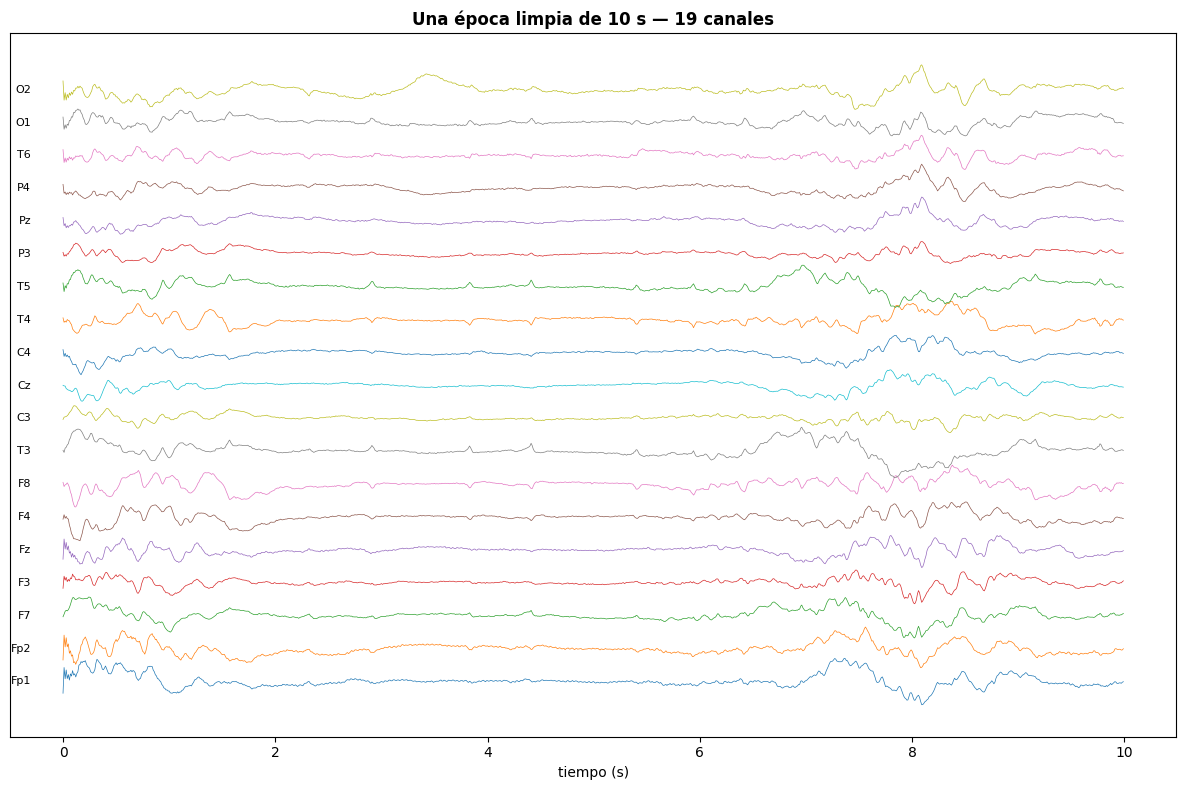

In [8]:
ep = clean.get_data()[0]                    # (19, 1000)
t = np.arange(ep.shape[1]) / clean.info["sfreq"]
step = 6 * np.std(ep)

fig, ax = plt.subplots(figsize=(12, 8))
for i, chn in enumerate(pp.CANONICAL_CHANNELS):
    ax.plot(t, ep[i] + i * step, lw=0.5)
    ax.text(-0.3, i * step, chn, va="center", ha="right", fontsize=8)
ax.set_title("Una época limpia de 10 s — 19 canales", fontweight="bold")
ax.set_xlabel("tiempo (s)"); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 8. Paciente completo y batch

Para procesar un paciente entero (todos sus segmentos en ventana, con cap y rechazo):

```python
epochs = pp.preprocess_patient(PATIENT)   # devuelve las ~2000 épocas limpias con su etiqueta
```

Para procesar los 17 pacientes de desarrollo y guardar un `-epo.fif` por paciente en
`development/data_processed/`:

```python
summary = pp.run_batch()   # ~18 min; una fila por paciente
```

Estos archivos son la entrada de la **Fase 3 (extracción de features)**.